<a href="https://colab.research.google.com/github/Hongleili/KV7006/blob/main/KV7006_Week_02_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intercept: 4.14
Coefficient (Slope): 2.80
MSE (Mean Squared Error): 0.65


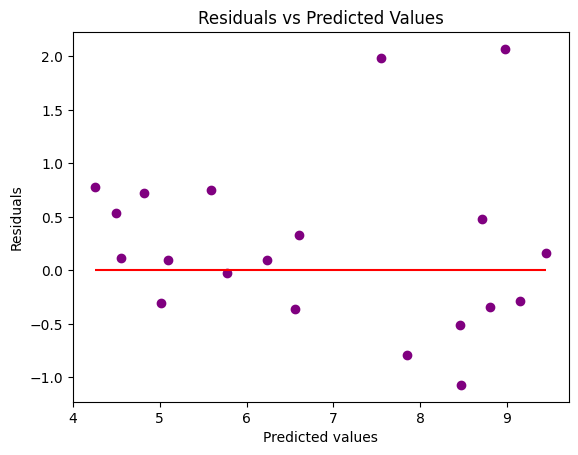

In [17]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data with one feature
X = 2 * np.random.rand(100, 1) # One feature
y = 4 + 3 * X + np.random.randn(100, 1) # y depends on the single feature

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)


# Initialise the Linear Regression model
lin_reg = LinearRegression()
# Model training to find the optimal slope and intercept
# Fit the model to the training data
lin_reg.fit(X_train, y_train)

# extract the coefficients of the model i.e. the slope and intercept of the best fitting
#line
print(f"Intercept: {lin_reg.intercept_[0]:.2f}")
print(f"Coefficient (Slope): {lin_reg.coef_[0][0]:.2f}")
 #Now that we trained a linear regression model, we can use the trained model to predict
#on the test set
y_pred = lin_reg.predict(X_test)

# Calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f"MSE (Mean Squared Error): {mse:.2f}")


# Calculate residuals
residuals = y_test - y_pred
# Plot residuals
plt.scatter(y_pred, residuals, color='purple')
# Plot a horizontal line at zero
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

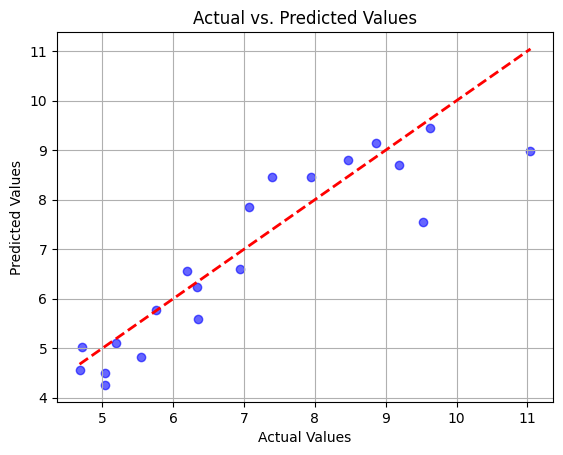

In [18]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()

Intercept: 4.49
Coefficients: [2.68156131 2.05119376]
Mean Squared Error: 1.00


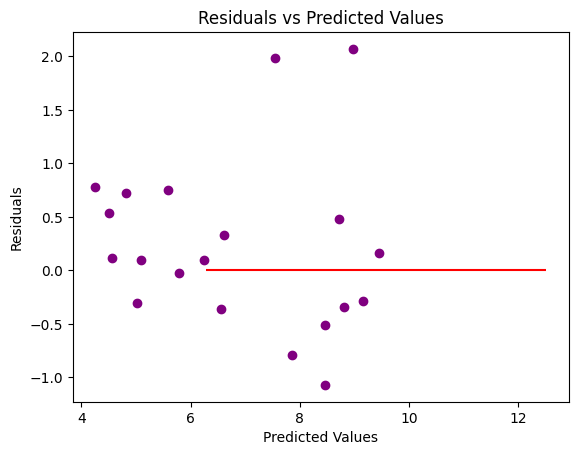

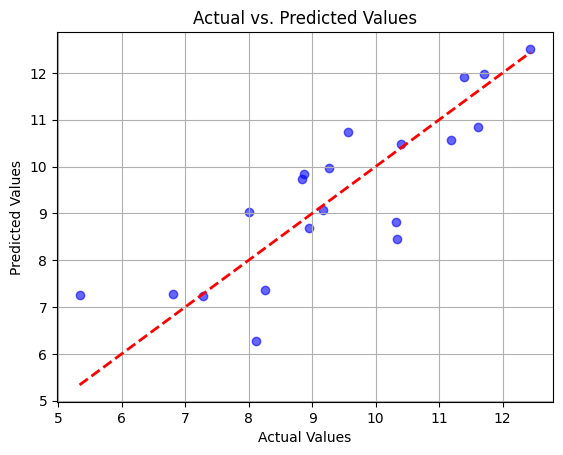

In [23]:
# Generate synthetic data with two features
X_multi = 2 * np.random.rand(100, 2)
y_multi = 4 + 3 * X_multi[:, 0] + 2 * X_multi[:, 1] + np.random.randn(100)
# Split the dataset
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi,
test_size=0.2, random_state=42)
# Initialize and fit the model
lin_reg_m = LinearRegression()
lin_reg_m.fit(X_train_m, y_train_m)
# Predict and evaluate
y_pred_m = lin_reg_m.predict(X_test_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
# Show results intercept, slope and MSE
print(f"Intercept: {lin_reg_m.intercept_:.2f}")
print(f"Coefficients: {lin_reg_m.coef_}")
print(f"Mean Squared Error: {mse_m:.2f}")
# Calculate residuals
residuals_m = y_test - y_pred
# Plot residuals
plt.scatter(y_pred, residuals, color='purple')
plt.hlines(y=0, xmin=y_pred_m.min(), xmax=y_pred_m.max(), colors='red')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

plt.scatter(y_test_m, y_pred_m, color='blue', alpha=0.6)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()

Iteration 100: SSE = 84.8799, a = 3.2983, b = 3.3238
Iteration 200: SSE = 74.7923, a = 3.2763, b = 3.5986
Iteration 300: SSE = 71.9168, a = 3.1686, b = 3.7283
Iteration 400: SSE = 70.2285, a = 3.0827, b = 3.8250
Iteration 500: SSE = 69.2350, a = 3.0167, b = 3.8990

Training complete.
Learned slope (a): 3.0167
Learned intercept (b): 3.8990


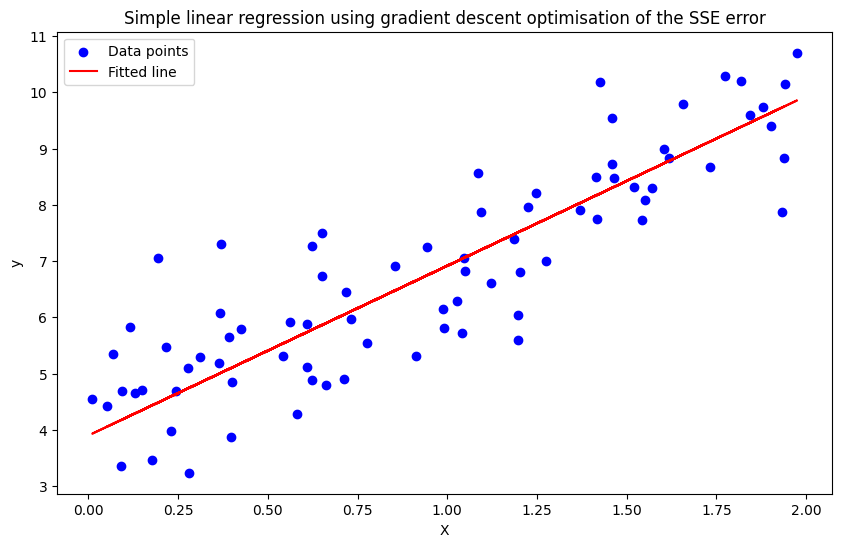

In [35]:
# Use ethe same synthetic dataset from the previous task
X = X_train
y = y_train
# Initialise the slope (a) and the intercept (b) to zero
a = 0.0
b = 0.0
# Learning rate for gradient descent
learning_rate = 0.0001
# Number of iterations for training
num_iterations = 500

def compute_sse(X, y, a, b):
    """
    This function computes the Sum of Squared Errors (SSE)
    Inputs <--- :
    - X: Input feature array
    - y: True target values
    - a: Current slope
    - b: Current intercept
    Output --->:
    - sse: Sum of Squared Errors
    """
    predictions = a * X + b
    sse = np.sum((predictions - y) ** 2)
    return sse

# Lists to store the history of parameters and loss
a_history = []
b_history = []
sse_history = []
for i in range(num_iterations):
    # Compute predictions with current parameters
    y_pred = a * X + b
    # Compute the current SSE (error or loss E)
    E = compute_sse(X, y, a, b)
    # Record the history of parameters and loss for visualisation
    sse_history.append(E)
    a_history.append(a)
    b_history.append(b)
    # Compute gradients i.e derivative of the error function SSE with respect to the
    #slope a and intercept b
    # The derivative of SSE with respect to a is given by: dE/da = 2 * sum(X * (y_pred- y))
    dEda = 2 * np.sum(X * (y_pred - y))
    # The derivative of SSE with respect to b is given by: dE/db = 2 * sum(y_pred - y)
    dEdb = 2 * np.sum(y_pred - y)
    # Update parameters using the gradients
    a = a - learning_rate * dEda
    b = b - learning_rate * dEdb
    # Print the values of the SSE error, slope a and intercept b every 100 iterations
    if (i + 1) % 100 == 0:
        print(f"Iteration {i + 1}: SSE = {E:.4f}, a = {a:.4f}, b = {b:.4f}")

# print the learned parameters
print("\nTraining complete.")
print(f"Learned slope (a): {a:.4f}")
print(f"Learned intercept (b): {b:.4f}")
#Plot the synthetic data along with the fitted regression line.
# Plot the synthetic data and the fitted regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, a * X + b, color='red', label='Fitted line')
plt.title('Simple linear regression using gradient descent optimisation of the SSE error')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

Iteration 100: SSE = 68.6503, a = 2.9661, b = 3.9558
Iteration 200: SSE = 68.3063, a = 2.9273, b = 3.9994
Iteration 300: SSE = 68.1038, a = 2.8975, b = 4.0328
Iteration 400: SSE = 67.9847, a = 2.8746, b = 4.0585
Iteration 500: SSE = 67.9146, a = 2.8571, b = 4.0781


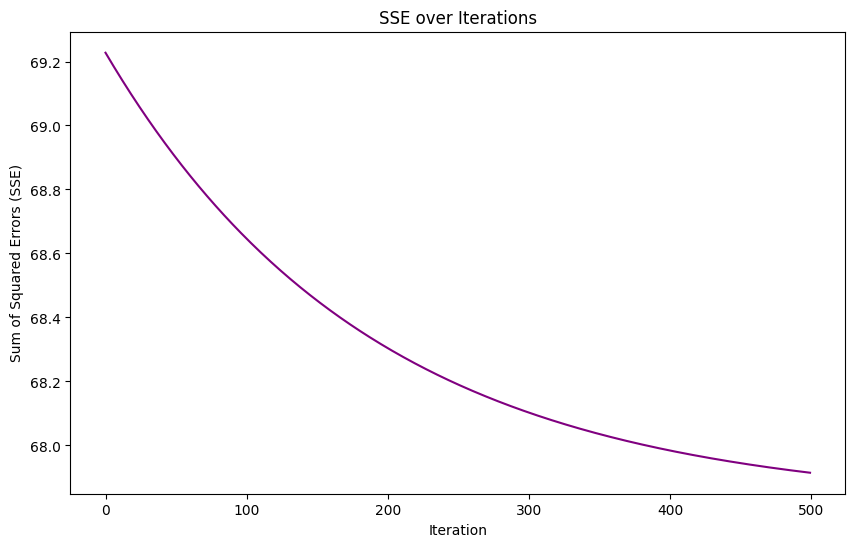

In [37]:
# Lists to store the history of parameters and loss
a_history = []
b_history = []
sse_history = []
error_change_threshold = 1e-4 # define a minimum threshold for error change
previous_error = float('inf') # set previous error to infinity
for i in range(num_iterations):
    # Compute predictions with current parameters
    y_pred = a * X + b
    # Compute the current SSE (error or loss E)
    E = compute_sse(X, y, a, b)
    # Record the history of parameters and loss for visualisation
    sse_history.append(E)
    a_history.append(a)
    b_history.append(b)
    # Compute gradients (derivative of SSE with respect to slope a and intercept b)
    # The derivative of SSE with respect to a is given by: dE/da = 2 * sum(X * (y_pred - y))
    dEda = 2 * np.sum(X * (y_pred - y))
    # The derivative of SSE with respect to b is given by: dE/db = 2 * sum(y_pred - y)
    dEdb = 2 * np.sum(y_pred - y)
    # Update parameters using the gradients
    a = a - learning_rate * dEda
    b = b - learning_rate * dEdb
    # Check for early convergence
    if abs(previous_error - E) < error_change_threshold:
        print(f"Converged after {i+1} iterations.")
        break
    previous_error = E
    # Print the values of the SSE error, slope a and intercept b every 100 iterations
    if (i + 1) % 100 == 0:
        print(f"Iteration {i + 1}: SSE = {E:.4f}, a = {a:.4f}, b = {b:.4f}")

# Plot the SEE over iterations to visualise its convergence
plt.figure(figsize=(10, 6))
plt.plot(range(i+1), sse_history, color='purple')
plt.title('SSE over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64
Training set: (40, 3), Test set: (10, 3)
Mean Squared Error (MSE): 80926321.22


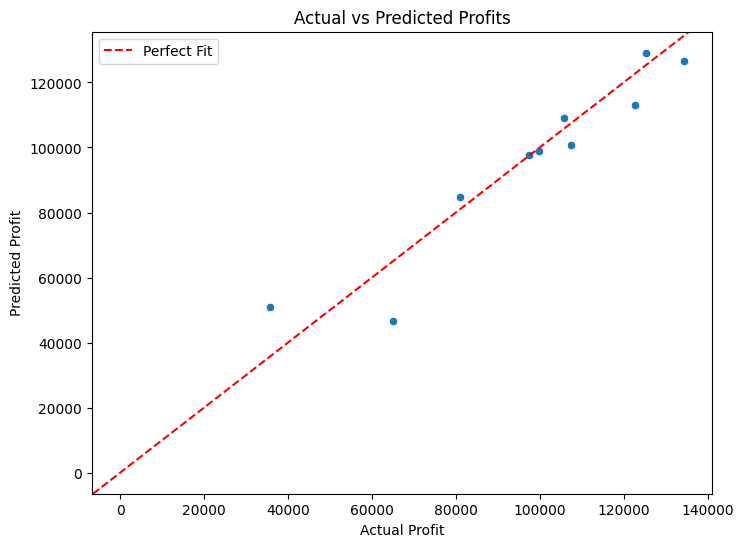

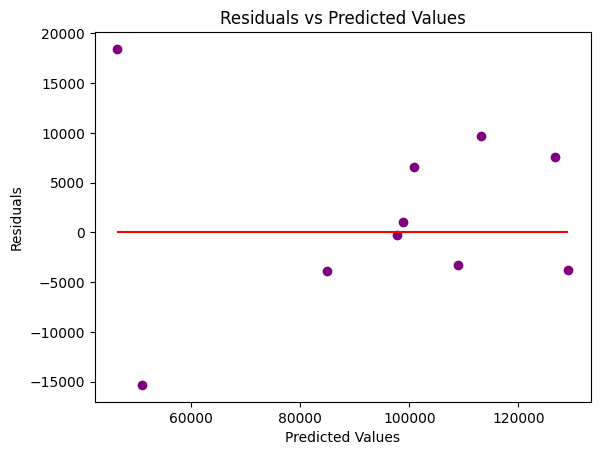

In [42]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Load the dataset
df = pd.read_csv("/content/sample_data/50_Startups.csv")
# Display the first few rows of the dataset
print(df.head())
# Check for missing values
print(df.isnull().sum())
# Drop the categorical feature ('State')
df = df.drop(columns=['State'])
# Define features / independent variables (X) and target variable (y)
X = df.drop(columns=['Profit']) # X now contains the independent variables
y = df['Profit'] # y represents the dependent / target variable
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
# Print dataset shapes
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
# Display evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
#Task 3.3: Sample solution
# Scatter plot for actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profits")
plt.axline([0, 0], slope=1, color='red', linestyle='--', label="Perfect Fit")
plt.legend()
plt.show()
# Calculate residuals
residuals_m = y_test - y_pred
# Plot residuals
plt.scatter(y_pred, residuals_m, color='purple')
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()